In [1]:
import numpy as np
import matplotlib.pyplot as plt
import emcee

In [2]:
def lognormal_imf(m, m_c, sigma):
    """
    Lognormal Initial Mass Function (IMF)
    
    Parameters:
    -----------
    m : float or array-like
        Mass value(s) in solar masses
    m_c : float
        Characteristic mass (peak of the distribution)
    sigma : float
        Width parameter of the lognormal distribution
    
    Returns:
    --------
    xi : float or array
        IMF value ξ(m) (unnormalized)
    
    Formula:
    --------
    ξ(m) ∝ (1/m) * exp[-(ln m - ln m_c)² / (2σ²)]
    """
    m = np.asarray(m)
    
    # Calculate the lognormal IMF
    log_term = (np.log(m) - np.log(m_c))**2
    xi = (1/m) * np.exp(-log_term / (2 * sigma**2))
    
    return xi

Generating 10000 stars...


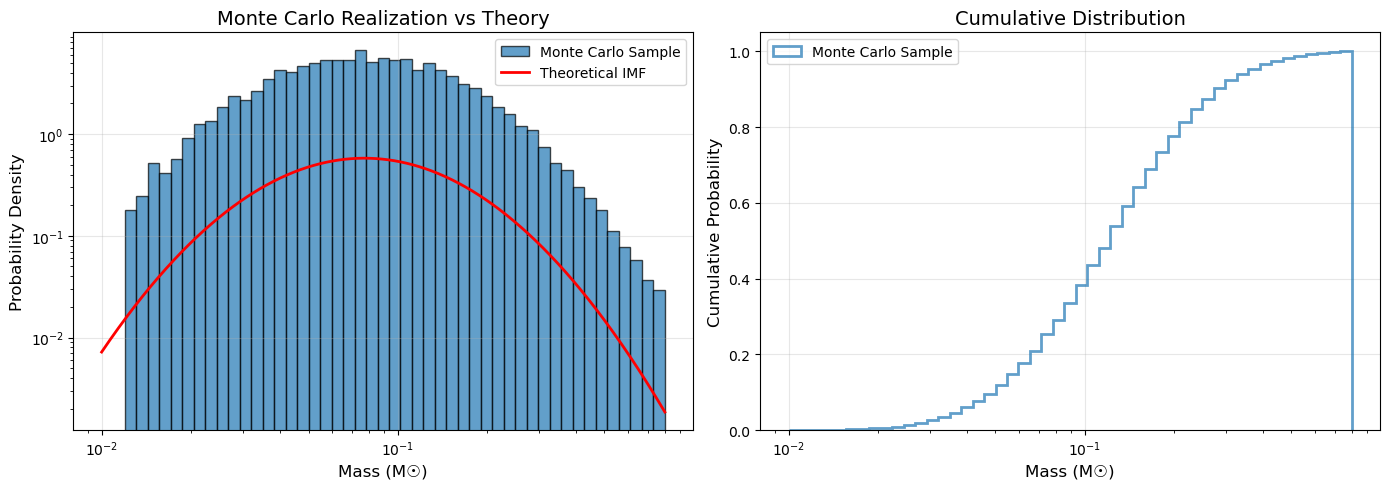


Statistics of synthetic population:
Total stars: 10000
Mean mass: 0.156 M☉
Median mass: 0.126 M☉
Min mass: 0.012 M☉
Max mass: 0.797 M☉
Stars below 0.5 M☉: 9809 (98.1%)


In [3]:
def draw_masses_from_imf(n_stars, m_min, m_max, m_c, sigma):
    """
    Draw a synthetic population of stellar masses using Monte Carlo sampling
    
    Parameters:
    -----------
    n_stars : int
        Number of stars to generate
    m_min : float
        Minimum mass (solar masses)
    m_max : float
        Maximum mass (solar masses)
    m_c : float
        Characteristic mass
    sigma : float
        Width parameter
    
    Returns:
    --------
    masses : array
        Array of stellar masses drawn from the IMF
    """
    # Method: Rejection sampling (Monte Carlo)
    
    # Find the maximum value of the IMF in our range for rejection sampling
    test_masses = np.logspace(np.log10(m_min), np.log10(m_max), 10000)
    imf_max = np.max(lognormal_imf(test_masses, m_c, sigma))
    
    masses = []
    
    while len(masses) < n_stars:
        # Draw random mass (uniformly in log space for better sampling)
        candidate_m = 10**(np.random.uniform(np.log10(m_min), np.log10(m_max)))
        
        # Draw random acceptance value
        u = np.random.uniform(0, imf_max)
        
        # Accept or reject based on IMF value
        if u <= lognormal_imf(candidate_m, m_c, sigma):
            masses.append(candidate_m)
    
    return np.array(masses)


# Generate synthetic population
n_stars = 10000
m_min = 0.01  # solar masses
m_max = 0.8   # solar masses
m_c = 0.2
sigma = 0.69

print(f"Generating {n_stars} stars...")
synthetic_masses = draw_masses_from_imf(n_stars, m_min, m_max, m_c, sigma)

# Visualize the results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: Histogram vs theoretical IMF
axes[0].hist(synthetic_masses, bins=np.logspace(np.log10(m_min), np.log10(m_max), 50), 
             density=True, alpha=0.7, label='Monte Carlo Sample', edgecolor='black')

# Overlay theoretical IMF (normalized)
m_theory = np.logspace(np.log10(m_min), np.log10(m_max), 1000)
imf_theory = lognormal_imf(m_theory, m_c, sigma)
# Normalize to match histogram
from scipy import integrate
norm_factor = integrate.simpson(imf_theory / m_theory, np.log(m_theory))
imf_normalized = imf_theory / norm_factor / m_theory

axes[0].plot(m_theory, imf_normalized, 'r-', linewidth=2, label='Theoretical IMF')
axes[0].set_xscale('log')
axes[0].set_yscale('log')
axes[0].set_xlabel('Mass (M☉)', fontsize=12)
axes[0].set_ylabel('Probability Density', fontsize=12)
axes[0].set_title('Monte Carlo Realization vs Theory', fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right panel: Cumulative distribution
axes[1].hist(synthetic_masses, bins=np.logspace(np.log10(m_min), np.log10(m_max), 50),
             cumulative=True, density=True, alpha=0.7, histtype='step', 
             linewidth=2, label='Monte Carlo Sample')
axes[1].set_xscale('log')
axes[1].set_xlabel('Mass (M☉)', fontsize=12)
axes[1].set_ylabel('Cumulative Probability', fontsize=12)
axes[1].set_title('Cumulative Distribution', fontsize=14)
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print some statistics
print(f"\nStatistics of synthetic population:")
print(f"Total stars: {len(synthetic_masses)}")
print(f"Mean mass: {np.mean(synthetic_masses):.3f} M☉")
print(f"Median mass: {np.median(synthetic_masses):.3f} M☉")
print(f"Min mass: {np.min(synthetic_masses):.3f} M☉")
print(f"Max mass: {np.max(synthetic_masses):.3f} M☉")
print(f"Stars below 0.5 M☉: {np.sum(synthetic_masses < 0.5)} ({100*np.sum(synthetic_masses < 0.5)/len(synthetic_masses):.1f}%)")

In [4]:
# ---------------------------
# Log-prior
# ---------------------------
def log_prior(theta):
    alpha = theta[0]
    if 1.01 < alpha < 5.0:
        return 0.0
    return -np.inf


# ---------------------------
# Log-likelihood
# ---------------------------
def log_likelihood(theta, masses, m_min, m_max):
    alpha = theta[0]

    if alpha <= 1.0:
        return -np.inf

    N = len(masses)

    norm = (m_min**(1.0-alpha) - m_max**(1.0-alpha))

    if norm <= 0:
        return -np.inf

    term1 = N * np.log(alpha - 1.0)
    term2 = -N * np.log(norm)
    term3 = -alpha * np.sum(np.log(masses))

    return term1 + term2 + term3


# ---------------------------
# Log-posterior
# ---------------------------
def log_probability(theta, masses, m_min, m_max):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, masses, m_min, m_max)

In [5]:
def fit_alpha_mcmc(masses, m_min, m_max, nsteps=2000):

    ndim = 1
    nwalkers = 32

    p0 = 2.0 + 1e-2 * np.random.randn(nwalkers, ndim)

    sampler = emcee.EnsembleSampler(
        nwalkers, ndim,
        log_probability,
        args=(masses, m_min, m_max)
    )

    sampler.run_mcmc(p0, nsteps, progress=False)

    samples = sampler.get_chain(discard=500, flat=True)
    alpha_med = np.median(samples[:,0])
    alpha_err = np.std(samples[:,0])

    return alpha_med, alpha_err

In [34]:
n_stars = 10000
m_min_list = np.arange(0.1, 0.6, 0.1)  # solar masses
m_max = 0.8   # solar masses
m_c = 0.4#0.2
sigma = 0.69

alpha_fit_vals = []
alpha_fit_error_vals = []

for m_min in m_min_list:
    masses = draw_masses_from_imf(n_stars, m_min, m_max, m_c, sigma)

    alpha_fit, alpha_err = fit_alpha_mcmc(masses, m_min, m_max)

    alpha_fit_vals.append(
        alpha_fit -1)

    alpha_fit_error_vals.append(
        alpha_err)

Text(0, 0.5, 'Fit alpha')

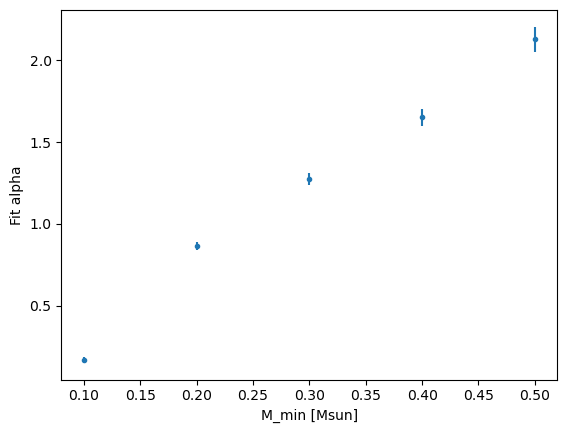

In [35]:
plt.errorbar(m_min_list, alpha_fit_vals, yerr = alpha_fit_error_vals, marker='.', linestyle='None')
plt.xlabel('M_min [Msun]')
plt.ylabel('Fit alpha')

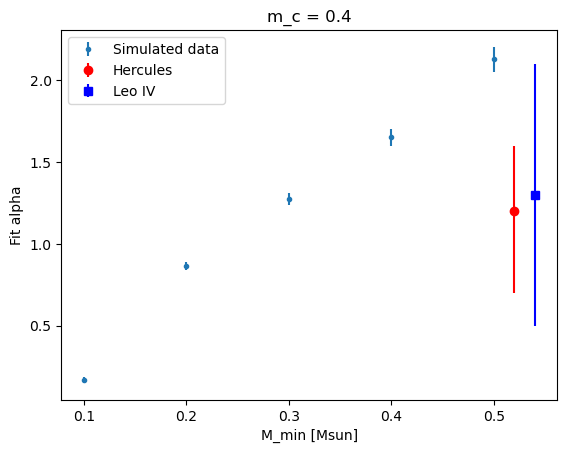

In [36]:
# Extract data for plotting
hercules_m_min = 0.52
hercules_alpha = 1.2
hercules_alpha_error = [[0.5], [0.4]]  # [[lower], [upper]] for asymmetric errors

leo_iv_m_min = 0.54
leo_iv_alpha = 1.3
leo_iv_alpha_error = 0.8  # symmetric error

# Add to your existing plot
plt.errorbar(m_min_list, alpha_fit_vals, yerr=alpha_fit_error_vals, marker='.', linestyle='None', label='Simulated data')

# Add Hercules
plt.errorbar(hercules_m_min, hercules_alpha, yerr=hercules_alpha_error, 
             marker='o', linestyle='None', color='red', label='Hercules')

# Add Leo IV
plt.errorbar(leo_iv_m_min, leo_iv_alpha, yerr=leo_iv_alpha_error, 
             marker='s', linestyle='None', color='blue', label='Leo IV')

plt.xlabel('M_min [Msun]')
plt.ylabel('Fit alpha')
plt.title('m_c = 0.4')
plt.legend()